## 

In [1]:
import numpy as np
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## **Data Preprocessing**

We preprocess the AT&T Faces dataset using the following steps:

1. **Convert to Grayscale**: Ensure all images are in grayscale mode (already grayscale in this dataset)

2. **Normalize Pixel Values**: Scale pixel values from [0, 255] to [0, 1] by dividing by 255

3. **Flatten Images**: Convert 2D images (112×92 pixels) into 1D vectors of 10,304 dimensions

4. **Train/Test Split**: Divide the dataset into:
   - **70% Training** (280 images - 7 per person)
   - **30% Testing** (120 images - 3 per person)
   - Split is stratified to ensure proportional representation of each class

5. **Standardize Data**: Apply Z-score normalization to center the data (mean=0) and scale it (std=1) by:
   - Computing mean and standard deviation from training data
   - Applying transformation: `(X - mean) / std` to both train and test sets

6. **No Face Alignment**: Images are already aligned, so no additional alignment is needed

In [ ]:
def load_dataset(dataset_path):
    """
    Load images and labels from the dataset directory.
    Args:
        dataset_path: Path to the dataset directory.
    Returns:
        images: Numpy array of shape (num_samples, height, width) with normalized pixel values.
        labels: Numpy array of shape (num_samples,) with integer class labels.
    """

    class_folders = sorted([d for d in dataset_path.iterdir() if d.is_dir()], key=lambda x: int(x.name[1:]))
    class_names = [folder.name for folder in class_folders]

    images, labels = [], []

    for class_idx, class_folder in enumerate(class_folders):
        image_files = sorted(class_folder.glob('*.pgm'), 
                            key=lambda x: int(x.stem))
        
        for img_file in image_files:
            try:
                # Load image
                img = Image.open(img_file)
                
                # Convert to grayscale (images are already grayscale, but ensure mode 'L')
                if img.mode != 'L':
                    img = img.convert('L')
                
                # Convert to numpy array
                img_array = np.array(img, dtype=np.float32)
                
                # Normalize pixel values to [0, 1]
                img_array = img_array / 255.0

                images.append(img_array)
                labels.append(class_idx)

            except Exception as e:
                print(f"    Error loading {img_file}: {e}")

    images = np.array(images)
    labels = np.array(labels)

    print(f"\nDataset loaded successfully from './{dataset_path}'!")
    print(f"  Total images: {len(images)}")
    print(f"  Number of classes: {len(class_names)}")
    print(f"  Image shape: {images[0].shape} (Height x Width)")

    return images, labels

dataset_path = Path("dataset")
X, y = load_dataset(dataset_path)


Dataset loaded successfully from './dataset'!
  Total images: 400
  Number of classes: 40
  Image shape: (112, 92) (Height x Width)


In [3]:
def flatten_images(images):
    """
    Flatten 2D images into 1D vectors

    Args:
        images: Array of 2D images with shape (n_samples, height, width)
        
    Returns:
        Flattened images with shape (n_samples, height*width)
    """
    n_samples = images.shape[0]
    flattened = images.reshape(n_samples, -1)

    print(f"\nImages flattened successfully!")
    print(f"  New data shape: {flattened[0].shape}")
    return flattened

X_flat = flatten_images(X)


Images flattened successfully!
  New data shape: (10304,)


In [4]:
def split_dataset(X, y, test_size=0.3, random_state=42):
    """
    Split dataset into 70% training and 30% testing sets (stratified).
        
    Args:
        X: Flattened image data
        y: Corresponding labels
        test_size: Proportion of dataset for testing (default: 0.3 for 30%)
        random_state: Random seed for reproducibility
        
    Returns:
        X_train, X_test, y_train, y_test (all flattened)
    """
    if len(X) == 0:
        raise ValueError("Dataset not loaded. Call load_dataset() first.")
    
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state,
        stratify=y
    )
    
    print(f"\nSplitted dataset into 70% training and 30% testing...")
    print(f"  Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_dataset(X_flat, y)


Splitted dataset into 70% training and 30% testing...
  Training samples: 280 (70.0%)
  Testing samples: 120 (30.0%)


In [5]:
def standardize_data(X_train, X_test):
    """
    Standardize the data by subtracting mean and dividing by std (Z-score normalization).
    
    Args:
        X_train: Training data (flattened)
        X_test: Testing data (flattened)
        
    Returns:
        X_train_standardized, X_test_standardized, mean_image, std_image
    """
    
    # Calculate mean and std from training data
    mean_image = np.mean(X_train, axis=0)
    std_image = np.std(X_train, axis=0)
    
    # Add small epsilon to avoid division by zero
    epsilon = 1e-8
    std_image = std_image + epsilon
    
    # Standardize training data: (X - mean) / std
    X_train_standardized = (X_train - mean_image) / std_image

    # Standardize testing data using training mean and std
    X_test_standardized = (X_test - mean_image) / std_image

    print(f"\nStandardized data (mean=0, std=1)...")
    print(f"  Mean image shape: {mean_image.shape}")
    print(f"  Std image shape: {std_image.shape}")
    print(f"  Standardized training data - Mean: {X_train_standardized.mean():.6f}, Std: {X_train_standardized.std():.6f}")
    print(f"  Standardized testing data - Mean: {X_test_standardized.mean():.6f}, Std: {X_test_standardized.std():.6f}")

    return X_train_standardized, X_test_standardized, mean_image, std_image

X_train_standardized, X_test_standardized, mean_image, std_image = standardize_data(X_train, X_test)


Standardized data (mean=0, std=1)...
  Mean image shape: (10304,)
  Std image shape: (10304,)
  Standardized training data - Mean: -0.000001, Std: 1.000000
  Standardized testing data - Mean: 0.013237, Std: 0.992460


## **Visualize Training Data**

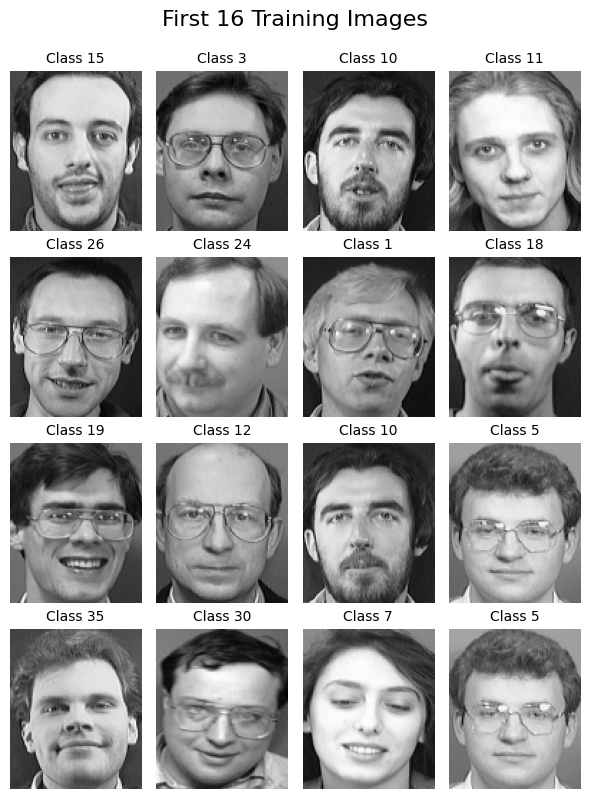

In [6]:
def visualize_training_samples(X_train, y_train, mean_image, std_image, n_samples=16, grid_size=(4, 4)):
    """
    Visualize the first n samples from the training dataset in a grid.
    
    Args:
        X_train: Standardized, flattened training data
        y_train: Training labels
        mean_image: Mean training image (for reconstruction)
        std_image: Std training image (for reconstruction)
        n_samples: Number of samples to visualize (default: 16)
        grid_size: Grid dimensions as (rows, cols) (default: (4, 4))
    """
    rows, cols = grid_size
    
    # Create figure with subplots
    fig, axes = plt.subplots(rows, cols, figsize=(6, 8))
    fig.suptitle('First 16 Training Images', fontsize=16, y=0.995)
    
    for idx in range(min(n_samples, rows * cols)):
        row = idx // cols
        col = idx % cols
        
        # Reconstruct image by reversing standardization: X_original = X_std * std + mean
        reconstructed = (X_train[idx] * std_image) + mean_image
        
        # Reshape to 2D image (112, 92)
        image_2d = reconstructed.reshape(112, 92)
        
        # Display image
        axes[row, col].imshow(image_2d, cmap='gray')
        axes[row, col].set_title(f'Class {y_train[idx]}', fontsize=10)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize first 16 training samples
visualize_training_samples(X_train_standardized, y_train, mean_image, std_image)

## **Dimensionality Reduction**

This section explores different dimensionality reduction method such as Principal Component Analysis (PCA), Linear Discriminant Analysis (LDA), and Fisherfaces (combination of PCA and LDA). For each of these methods, we will use both K-Nearest Neighbors and Minimum Mahalanobis Distance Classifier to classify the data into its respective class.

In [17]:
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

### **Principal Component Analysis (PCA)**
PCA is one of the most common methods of unsupervised linear projection to transform high-dimensionality data to a smaller vector subspace by maximizing the input variance. By varying the value of k, we can learn the effect of dimensionality on classification performance. 

In [33]:
n_components_list = [5, 10, 15, 20, 50, 100, 200]
k_values = [3, 5, 7, 9, 11, 13, 15]

class MahalanobisClassifier:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = {}
        self.cov_inv_ = {}

        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = Xc.mean(axis=0)
            # Use regularized covariance if n_samples < n_features
            cov = np.cov(Xc, rowvar=False)
            cov += np.eye(cov.shape[0]) * 1e-6  # regularization
            self.cov_inv_[c] = np.linalg.inv(cov)
        return self

    def predict(self, X):
        y_pred = []
        for x in X:
            distances = []
            for c in self.classes_:
                diff = x - self.means_[c]
                d = np.sqrt(diff.T @ self.cov_inv_[c] @ diff)
                distances.append(d)
            y_pred.append(self.classes_[np.argmin(distances)])
        return np.array(y_pred)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [ ]:
knn_val_scores_dict = {}
knn_test_scores_dict = {}

for n_components in n_components_list:
    val_scores = []
    test_scores = []

    for k in k_values:
        pipe = Pipeline([
            ('pca', PCA(n_components=n_components)),
            ('knn', KNeighborsClassifier(n_neighbors=k))
        ])
        
        # Cross-validation score on training data
        cv_score = cross_val_score(pipe, X_train_standardized, y_train, cv=5, scoring='accuracy').mean()
        val_scores.append((k, cv_score))
        
        # Train on full training set and test on test set
        pipe.fit(X_train_standardized, y_train)
        test_score = pipe.score(X_test_standardized, y_test)
        test_scores.append((k, test_score))
    
    knn_val_scores_dict[n_components] = val_scores
    knn_test_scores_dict[n_components] = test_scores

# Find and print best configuration
best_config = max(
    ((n_comp, k, score) for n_comp, scores in knn_test_scores_dict.items() for k, score in scores),
    key=lambda x: x[2]
)
print(f"\nBest configuration on test set:")
print(f"  PCA components: {best_config[0]}")
print(f"  k neighbors: {best_config[1]}")
print(f"  Test accuracy: {best_config[2]:.4f}")

/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/bebekjk/code/ie4476/.venv/lib/python3.12


Best configuration on test set:
  PCA components: 200
  k neighbors: 3
  Test accuracy: 0.8833


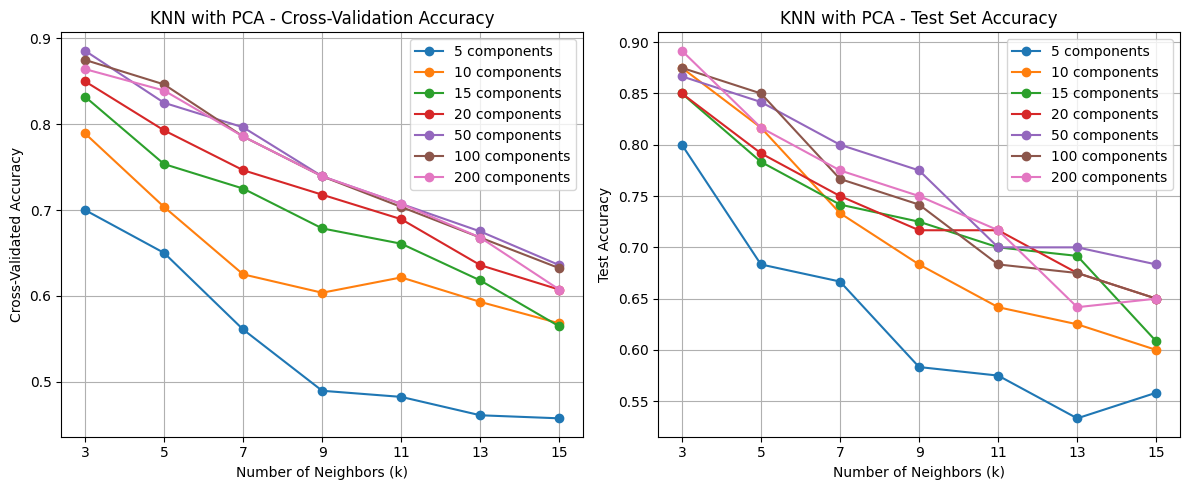

In [ ]:
# Plot cross-validation results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for n_components, scores in knn_val_scores_dict.items():
    k_vals, acc_vals = zip(*scores)
    plt.plot(k_vals, acc_vals, marker='o', label=f'{n_components} components')
plt.title('KNN with PCA - Cross-Validation Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

# Plot test set results
plt.subplot(1, 2, 2)
for n_components, scores in knn_test_scores_dict.items():
    k_vals, acc_vals = zip(*scores)
    plt.plot(k_vals, acc_vals, marker='o', label=f'{n_components} components')
plt.title('KNN with PCA - Test Set Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
mdc_train_scores = []
mdc_test_scores = []
for n_components in n_components_list:
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_standardized)
    X_test_pca = pca.transform(X_test_standardized)

    # Train Mahalanobis classifier
    clf = MahalanobisClassifier()
    clf.fit(X_train_pca, y_train)

    # Evaluate
    train_accuracy = clf.score(X_train_pca, y_train)
    test_accuracy = clf.score(X_test_pca, y_test)
    
    mdc_train_scores.append(train_accuracy)
    mdc_test_scores.append(test_accuracy)

    print(f"PCA {n_components:3d} components - Train: {train_accuracy:.4f}, Test: {test_accuracy:.4f}")

Train accuracy:  0.9964285714285714
Test accuracy: 0.6916666666666667
Train accuracy:  1.0
Test accuracy: 0.9416666666666667
Train accuracy:  1.0
Test accuracy: 0.95
Train accuracy:  1.0
Test accuracy: 0.9416666666666667
Train accuracy:  1.0
Test accuracy: 0.9666666666666667
Train accuracy:  1.0
Test accuracy: 0.9583333333333334
Train accuracy:  1.0
Test accuracy: 0.975


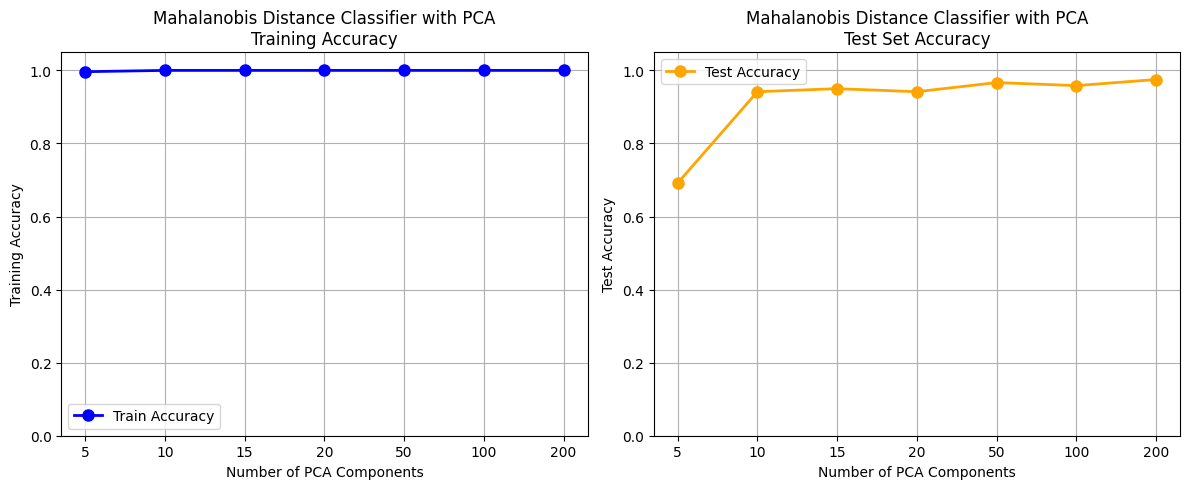


Best configuration on test set:
  PCA components: 200
  Test accuracy: 0.9750


In [31]:
# Plot Mahalanobis Distance Classifier results
plt.figure(figsize=(12, 5))

# Use log scale or categorical x-axis for better spacing
x_positions = np.arange(len(n_components_list))

plt.subplot(1, 2, 1)
plt.plot(x_positions, mdc_train_scores, marker='o', linewidth=2, markersize=8, color='blue', label='Train Accuracy')
plt.title('Mahalanobis Distance Classifier with PCA\nTraining Accuracy')
plt.xlabel('Number of PCA Components')
plt.ylabel('Training Accuracy')
plt.grid(True)
plt.xticks(x_positions, n_components_list)
plt.legend()
plt.ylim([0, 1.05])

plt.subplot(1, 2, 2)
plt.plot(x_positions, mdc_test_scores, marker='o', linewidth=2, markersize=8, color='orange', label='Test Accuracy')
plt.title('Mahalanobis Distance Classifier with PCA\nTest Set Accuracy')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.xticks(x_positions, n_components_list)
plt.legend()
plt.ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Find and report best configuration
best_idx = np.argmax(mdc_test_scores)
best_n_components = n_components_list[best_idx]
print(f"\nBest configuration on test set:")
print(f"  PCA components: {best_n_components}")
print(f"  Test accuracy: {mdc_test_scores[best_idx]:.4f}")

### **Linear Discriminant Analysis (LDA)**

On the other hand, LDA is the supervised method for dimensionality reduction by maximizing class separability. In our case, since there are 40 classes, then the maximum number of discriminant features is 39. LDA also utilizes the class labels during training, and since our task is not to represent the original data but to discriminate the class membership of the data, this method is very suitable for our task.


In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA can extract at most min(n_classes-1, n_features) components
# With 40 classes, max is 39 components
lda_n_components_list = [5, 10, 15, 20, 25, 30, 35, 39]

# LDA with k-NN
lda_knn_val_scores_dict = {}
lda_knn_test_scores_dict = {}

for n_components in lda_n_components_list:
    val_scores = []
    test_scores = []

    for k in k_values:
        pipe = Pipeline([
            ('lda', LinearDiscriminantAnalysis(n_components=n_components)),
            ('knn', KNeighborsClassifier(n_neighbors=k))
        ])
        
        # Cross-validation score on training data
        cv_score = cross_val_score(pipe, X_train_standardized, y_train, cv=5, scoring='accuracy').mean()
        val_scores.append((k, cv_score))
        
        # Train on full training set and test on test set
        pipe.fit(X_train_standardized, y_train)
        test_score = pipe.score(X_test_standardized, y_test)
        test_scores.append((k, test_score))
    
    lda_knn_val_scores_dict[n_components] = val_scores
    lda_knn_test_scores_dict[n_components] = test_scores

# Find and print best configuration
best_config = max(
    ((n_comp, k, score) for n_comp, scores in lda_knn_test_scores_dict.items() for k, score in scores),
    key=lambda x: x[2]
)
print(f"\nBest k-NN configuration on test set:")
print(f"  LDA components: {best_config[0]}")
print(f"  k neighbors: {best_config[1]}")
print(f"  Test accuracy: {best_config[2]:.4f}")

/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/bebekjk/code/ie4476/.venv/lib/python3.12


Best k-NN configuration on test set:
  LDA components: 15
  k neighbors: 3
  Test accuracy: 0.9583


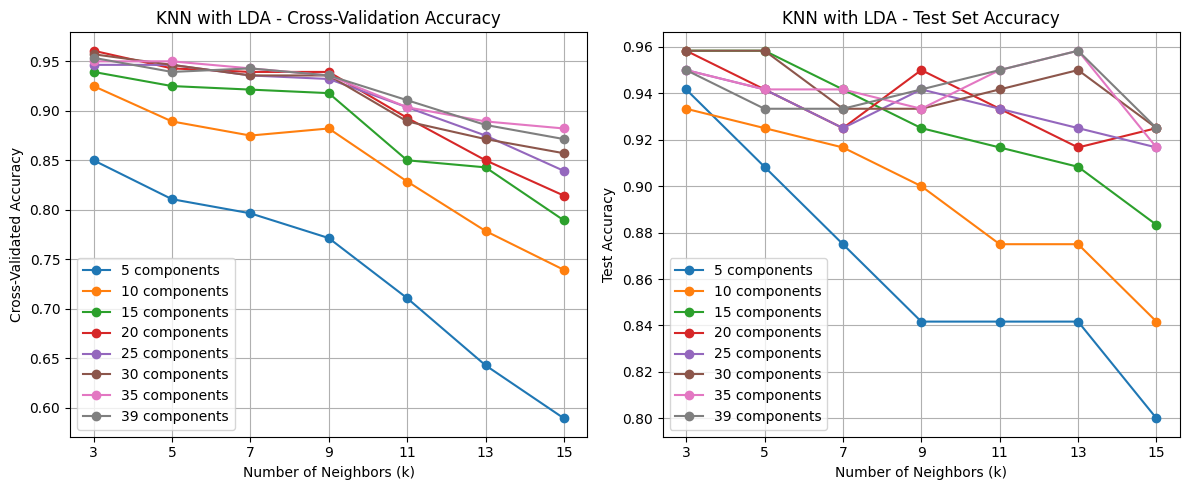

In [35]:
# Plot LDA + k-NN results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for n_components, scores in lda_knn_val_scores_dict.items():
    k_vals, acc_vals = zip(*scores)
    plt.plot(k_vals, acc_vals, marker='o', label=f'{n_components} components')
plt.title('KNN with LDA - Cross-Validation Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for n_components, scores in lda_knn_test_scores_dict.items():
    k_vals, acc_vals = zip(*scores)
    plt.plot(k_vals, acc_vals, marker='o', label=f'{n_components} components')
plt.title('KNN with LDA - Test Set Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
# LDA with Mahalanobis Distance Classifier
lda_mdc_train_scores = []
lda_mdc_test_scores = []

for n_components in lda_n_components_list:
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    X_train_lda = lda.fit_transform(X_train_standardized, y_train)
    X_test_lda = lda.transform(X_test_standardized)

    # Train Mahalanobis classifier
    clf = MahalanobisClassifier()
    clf.fit(X_train_lda, y_train)

    # Evaluate
    train_accuracy = clf.score(X_train_lda, y_train)
    test_accuracy = clf.score(X_test_lda, y_test)
    
    lda_mdc_train_scores.append(train_accuracy)
    lda_mdc_test_scores.append(test_accuracy)

    print(f"LDA {n_components:2d} components - Train: {train_accuracy:.4f}, Test: {test_accuracy:.4f}")

# Find and report best configuration
best_idx = np.argmax(lda_mdc_test_scores)
best_n_components = lda_n_components_list[best_idx]
print(f"\nBest Mahalanobis configuration on test set:")
print(f"  LDA components: {best_n_components}")
print(f"  Test accuracy: {lda_mdc_test_scores[best_idx]:.4f}")

LDA  5 components - Train: 0.9964, Test: 0.6667
LDA 10 components - Train: 1.0000, Test: 0.7667
LDA 15 components - Train: 1.0000, Test: 0.9667
LDA 20 components - Train: 1.0000, Test: 0.9417
LDA 25 components - Train: 1.0000, Test: 0.9583
LDA 30 components - Train: 1.0000, Test: 0.9417
LDA 35 components - Train: 1.0000, Test: 0.9250
LDA 39 components - Train: 1.0000, Test: 0.9417

Best Mahalanobis configuration on test set:
  LDA components: 15
  Test accuracy: 0.9667


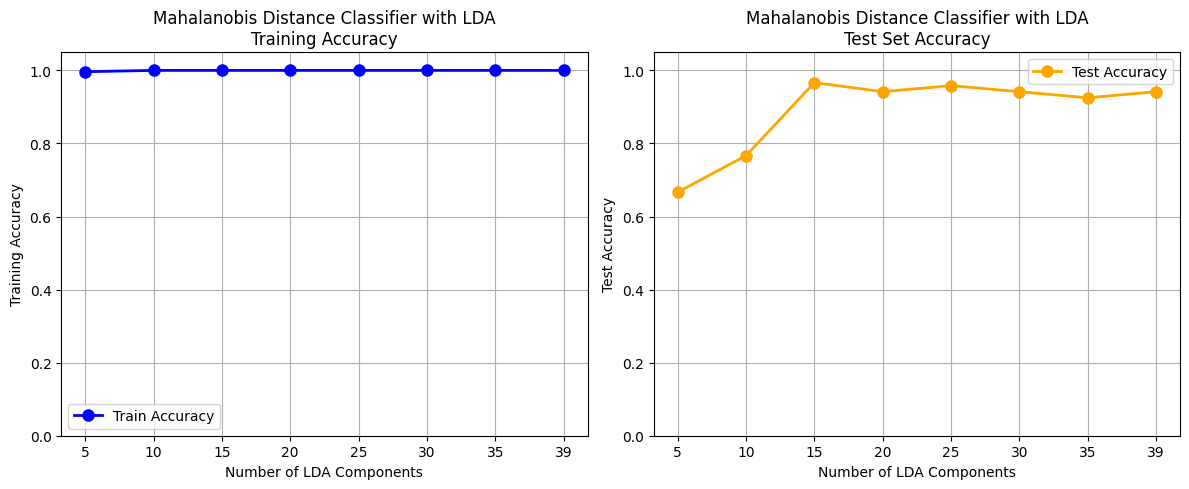

In [37]:
# Plot LDA + Mahalanobis Distance Classifier results
plt.figure(figsize=(12, 5))

# Use evenly spaced positions for better visualization
x_positions = np.arange(len(lda_n_components_list))

plt.subplot(1, 2, 1)
plt.plot(x_positions, lda_mdc_train_scores, marker='o', linewidth=2, markersize=8, color='blue', label='Train Accuracy')
plt.title('Mahalanobis Distance Classifier with LDA\nTraining Accuracy')
plt.xlabel('Number of LDA Components')
plt.ylabel('Training Accuracy')
plt.grid(True)
plt.xticks(x_positions, lda_n_components_list)
plt.legend()
plt.ylim([0, 1.05])

plt.subplot(1, 2, 2)
plt.plot(x_positions, lda_mdc_test_scores, marker='o', linewidth=2, markersize=8, color='orange', label='Test Accuracy')
plt.title('Mahalanobis Distance Classifier with LDA\nTest Set Accuracy')
plt.xlabel('Number of LDA Components')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.xticks(x_positions, lda_n_components_list)
plt.legend()
plt.ylim([0, 1.05])

plt.tight_layout()
plt.show()

### **Fisherfaces**

Though PCA addresses the problem of reducing dataset complexity, some information that is lost during the process may serve as a key component while discriminating against class membership. While applying LDA directly against the original dataset is possible, given the very large dimension of the data (10,304 features) and the small dataset (400 samples), there is a risk that this method leads Sw to become irreversible, causing the resultant discriminant directions to be meaningless. 

To address this issue, a combination of both methods is used. First, we will reduce the number of features (from 10,304) to a manageable amount, such as 100, by using PCA just to ensure the noise features are removed. We then proceed to apply LDA to extract the most discriminative directions of dimensional reduction. This combination method is widely applied for computer vision tasks; specifically, for face recognition tasks, it is called Fisherfaces.

In [38]:
# Fisherfaces: PCA (100 components) + LDA
# First reduce to 100 dimensions with PCA, then apply LDA

fisherfaces_n_components_list = [5, 10, 15, 20, 25, 30, 35, 39]
pca_n_components_fisherfaces = 100

# Fisherfaces with k-NN
fisherfaces_knn_val_scores_dict = {}
fisherfaces_knn_test_scores_dict = {}

for lda_components in fisherfaces_n_components_list:
    val_scores = []
    test_scores = []

    for k in k_values:
        pipe = Pipeline([
            ('pca', PCA(n_components=pca_n_components_fisherfaces)),
            ('lda', LinearDiscriminantAnalysis(n_components=lda_components)),
            ('knn', KNeighborsClassifier(n_neighbors=k))
        ])
        
        # Cross-validation score on training data
        cv_score = cross_val_score(pipe, X_train_standardized, y_train, cv=5, scoring='accuracy').mean()
        val_scores.append((k, cv_score))
        
        # Train on full training set and test on test set
        pipe.fit(X_train_standardized, y_train)
        test_score = pipe.score(X_test_standardized, y_test)
        test_scores.append((k, test_score))
    
    fisherfaces_knn_val_scores_dict[lda_components] = val_scores
    fisherfaces_knn_test_scores_dict[lda_components] = test_scores

# Find and print best configuration
best_config = max(
    ((n_comp, k, score) for n_comp, scores in fisherfaces_knn_test_scores_dict.items() for k, score in scores),
    key=lambda x: x[2]
)
print(f"\nBest Fisherfaces k-NN configuration on test set:")
print(f"  PCA components: {pca_n_components_fisherfaces}")
print(f"  LDA components: {best_config[0]}")
print(f"  k neighbors: {best_config[1]}")
print(f"  Test accuracy: {best_config[2]:.4f}")

/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/bebekjk/code/ie4476/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/bebekjk/code/ie4476/.venv/lib/python3.12


Best Fisherfaces k-NN configuration on test set:
  PCA components: 100
  LDA components: 30
  k neighbors: 3
  Test accuracy: 0.9917


In [45]:
fisherfaces_knn_test_scores_dict

{5: [(3, 0.8666666666666667),
  (5, 0.8666666666666667),
  (7, 0.875),
  (9, 0.8833333333333333),
  (11, 0.875),
  (13, 0.9083333333333333),
  (15, 0.85)],
 10: [(3, 0.9666666666666667),
  (5, 0.95),
  (7, 0.9583333333333334),
  (9, 0.9583333333333334),
  (11, 0.9583333333333334),
  (13, 0.95),
  (15, 0.8666666666666667)],
 15: [(3, 0.9333333333333333),
  (5, 0.9666666666666667),
  (7, 0.9333333333333333),
  (9, 0.9583333333333334),
  (11, 0.9666666666666667),
  (13, 0.95),
  (15, 0.8916666666666667)],
 20: [(3, 0.95),
  (5, 0.9583333333333334),
  (7, 0.9666666666666667),
  (9, 0.975),
  (11, 0.975),
  (13, 0.9666666666666667),
  (15, 0.9)],
 25: [(3, 0.9666666666666667),
  (5, 0.975),
  (7, 0.9666666666666667),
  (9, 0.9583333333333334),
  (11, 0.975),
  (13, 0.975),
  (15, 0.925)],
 30: [(3, 0.9916666666666667),
  (5, 0.975),
  (7, 0.975),
  (9, 0.9833333333333333),
  (11, 0.9666666666666667),
  (13, 0.9666666666666667),
  (15, 0.925)],
 35: [(3, 0.9833333333333333),
  (5, 0.975),
  

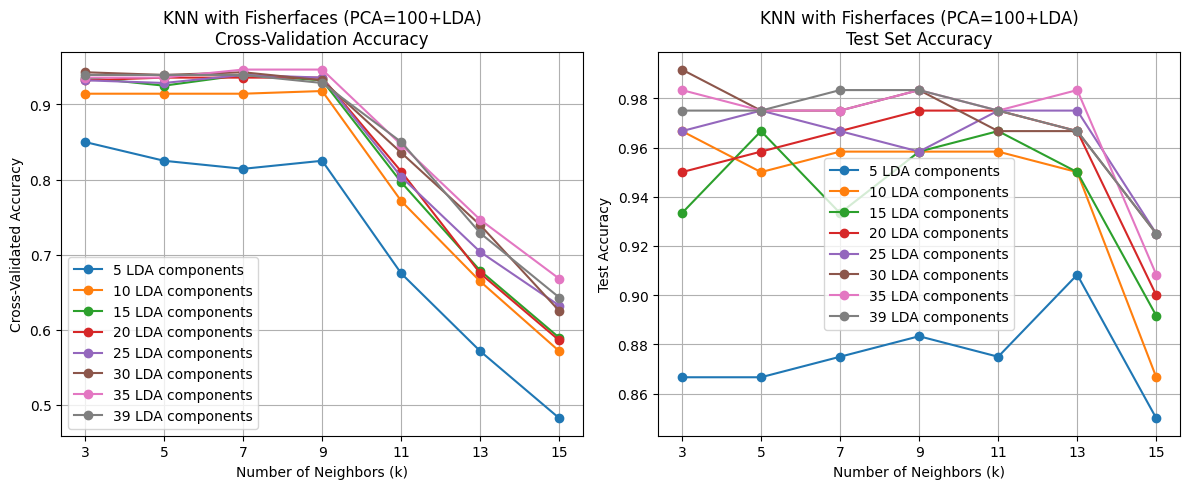

In [39]:
# Plot Fisherfaces + k-NN results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for n_components, scores in fisherfaces_knn_val_scores_dict.items():
    k_vals, acc_vals = zip(*scores)
    plt.plot(k_vals, acc_vals, marker='o', label=f'{n_components} LDA components')
plt.title(f'KNN with Fisherfaces (PCA={pca_n_components_fisherfaces}+LDA)\nCross-Validation Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for n_components, scores in fisherfaces_knn_test_scores_dict.items():
    k_vals, acc_vals = zip(*scores)
    plt.plot(k_vals, acc_vals, marker='o', label=f'{n_components} LDA components')
plt.title(f'KNN with Fisherfaces (PCA={pca_n_components_fisherfaces}+LDA)\nTest Set Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
# Fisherfaces with Mahalanobis Distance Classifier
fisherfaces_mdc_train_scores = []
fisherfaces_mdc_test_scores = []

# First apply PCA to reduce to 100 dimensions
pca = PCA(n_components=pca_n_components_fisherfaces)
X_train_pca = pca.fit_transform(X_train_standardized)
X_test_pca = pca.transform(X_test_standardized)

for lda_components in fisherfaces_n_components_list:
    # Apply LDA on PCA-reduced data
    lda = LinearDiscriminantAnalysis(n_components=lda_components)
    X_train_fisherfaces = lda.fit_transform(X_train_pca, y_train)
    X_test_fisherfaces = lda.transform(X_test_pca)

    # Train Mahalanobis classifier
    clf = MahalanobisClassifier()
    clf.fit(X_train_fisherfaces, y_train)

    # Evaluate
    train_accuracy = clf.score(X_train_fisherfaces, y_train)
    test_accuracy = clf.score(X_test_fisherfaces, y_test)
    
    fisherfaces_mdc_train_scores.append(train_accuracy)
    fisherfaces_mdc_test_scores.append(test_accuracy)

    print(f"Fisherfaces (PCA={pca_n_components_fisherfaces}, LDA={lda_components:2d}) - Train: {train_accuracy:.4f}, Test: {test_accuracy:.4f}")

# Find and report best configuration
best_idx = np.argmax(fisherfaces_mdc_test_scores)
best_lda_components = fisherfaces_n_components_list[best_idx]
print(f"\nBest Fisherfaces Mahalanobis configuration on test set:")
print(f"  PCA components: {pca_n_components_fisherfaces}")
print(f"  LDA components: {best_lda_components}")
print(f"  Test accuracy: {fisherfaces_mdc_test_scores[best_idx]:.4f}")

Fisherfaces (PCA=100, LDA= 5) - Train: 1.0000, Test: 0.7083
Fisherfaces (PCA=100, LDA=10) - Train: 1.0000, Test: 0.7500
Fisherfaces (PCA=100, LDA=15) - Train: 1.0000, Test: 0.9500
Fisherfaces (PCA=100, LDA=20) - Train: 1.0000, Test: 0.9500
Fisherfaces (PCA=100, LDA=25) - Train: 1.0000, Test: 0.9750
Fisherfaces (PCA=100, LDA=30) - Train: 1.0000, Test: 0.9750
Fisherfaces (PCA=100, LDA=35) - Train: 1.0000, Test: 0.9917
Fisherfaces (PCA=100, LDA=39) - Train: 1.0000, Test: 0.9833

Best Fisherfaces Mahalanobis configuration on test set:
  PCA components: 100
  LDA components: 35
  Test accuracy: 0.9917


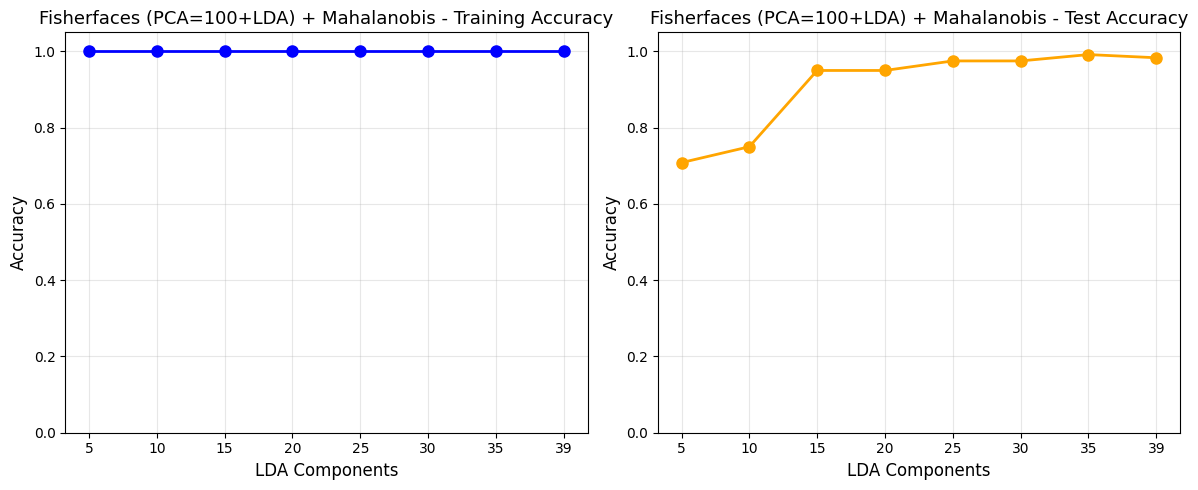

In [41]:
# Plot Fisherfaces + Mahalanobis Distance Classifier results
plt.figure(figsize=(12, 5))

x_positions = np.arange(len(fisherfaces_n_components_list))

# Plot training scores
plt.subplot(1, 2, 1)
plt.plot(x_positions, fisherfaces_mdc_train_scores, 'o-', linewidth=2, markersize=8, color='blue')
plt.xlabel('LDA Components', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Fisherfaces (PCA=100+LDA) + Mahalanobis - Training Accuracy', fontsize=13)
plt.xticks(x_positions, fisherfaces_n_components_list)
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)

# Plot test scores
plt.subplot(1, 2, 2)
plt.plot(x_positions, fisherfaces_mdc_test_scores, 'o-', linewidth=2, markersize=8, color='orange')
plt.xlabel('LDA Components', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Fisherfaces (PCA=100+LDA) + Mahalanobis - Test Accuracy', fontsize=13)
plt.xticks(x_positions, fisherfaces_n_components_list)
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Result and Analysis**